# HopeEXP — Task D: Outcome Stance & Actor
**Modelo base:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Clasificación de fragmentos (Spans). Hay dos subtareas:
1. **Outcome Stance**: Avoided, Desired
2. **Actor**: Self, Other, World/System, Unclear

**Nota**: Cada muestra de entrenamiento es un fragmento (span), no el texto completo del post.

## 0. Setup e Imports

In [1]:
%pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Añadir el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath("."))

from src.data_utils import (
    load_split,
    apply_cleaning,
    compute_class_weights,
)
from src.dataset import build_all_dataloaders
from src.model import (
    build_model, build_tokenizer, count_parameters,
    CANDIDATE_MODELS, list_candidate_models,
)
from src.trainer import train, compare_models

print("Imports correctos")

/Users/adrian/Documents/Universidad/PLN/Practica-PLN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports correctos


In [3]:
# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cpu


## 1. Configuración de Hiperparámetros

In [4]:
# ── Rutas de datos ────────────────────────────────────────────
TRAIN_PATH = "./HopeEXP_Train.jsonl"
DEV_SIZE   = 0.20

# ── Columnas del dataset ──────────────────────────────────────
TEXT_COL    = "span"

# ── Modelo ────────────────────────────────────────────────────
MODEL_NAME  = "microsoft/mdeberta-v3-base"
MAX_LENGTH  = 512
DROPOUT     = 0.1

# ── Entrenamiento ─────────────────────────────────────────────
BATCH_SIZE  = 16
COMPARISON_EPOCHS = 3
NUM_EPOCHS  = 25
LR          = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE    = 3

# ── Evaluación ────────────────────────────────────────────────
THRESHOLD   = 0.5
USE_POS_WEIGHT = True

# ── Salidas ───────────────────────────────────────────────────
OUTPUT_DIR     = "./outputs/task_d_roles_notebook"
COMPARISON_DIR = os.path.join(OUTPUT_DIR, "model_comparison")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(COMPARISON_DIR, exist_ok=True)
print("Configuración lista")

Configuración lista


## 2. Carga y Preprocesamiento de Datos

In [5]:
from sklearn.model_selection import train_test_split as sk_split

# Extraer spans de los datos
def load_task_d_data(filepath):
    all_data = pd.read_json(path_or_buf=filepath, lines=True)
    
    spans = []
    stances = []
    actors = []
    
    for _, row in all_data.iterrows():
        annotations = row.get("span_annotations", [])
        if isinstance(annotations, list):
            for ann in annotations:
                spans.append(ann["span"])
                stances.append(ann["outcome_stance"])
                
                actor = ann["actor"]
                if actor == "World/System":
                    actor = "World"
                actors.append(actor)
                
    df = pd.DataFrame({
        "span": spans,
        "outcome_stance": stances,
        "actor": actors
    })
    return df

full_train_df = load_task_d_data(TRAIN_PATH)

STANCE_LABELS = ["Avoided", "Desired"]
ACTOR_LABELS = ["Self", "Other", "World", "Unclear"]

# Convertir a listas para usar compute_class_weights
full_train_df["stance_list"] = full_train_df["outcome_stance"].apply(lambda x: [x])
full_train_df["actor_list"] = full_train_df["actor"].apply(lambda x: [x])

# Para el split, estratificamos por una combinación de stance y actor
full_train_df["stratify_col"] = full_train_df["outcome_stance"] + "_" + full_train_df["actor"]

# Limpiar clases con muy pocos ejemplos para stratify
stratify_counts = full_train_df["stratify_col"].value_counts()
valid_stratify = stratify_counts[stratify_counts > 1].index
full_train_df.loc[~full_train_df["stratify_col"].isin(valid_stratify), "stratify_col"] = "Other_Unclear" # Fallback

train_df, dev_df = sk_split(
    full_train_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=full_train_df["stratify_col"],
)

train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)

print(f"Spans totales: {len(full_train_df)}")
print(f"  → Train: {len(train_df)} | Dev: {len(dev_df)}  (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})\n")

display(train_df.head(3))

Spans totales: 3756
  → Train: 3004 | Dev: 752  (split 80/20)



,span,outcome_stance,actor,stance_list,actor_list,stratify_col
0,I'm absolutely certain that removing all perso...,Desired,World,[Desired],[World],Desired_World
1,"Yeah, I'm sure the immigration office will jus...",Desired,Other,[Desired],[Other],Desired_Other
2,"If I can be honest with her about my anxiety, ...",Desired,Self,[Desired],[Self],Desired_Self


In [6]:
# ── Limpieza de texto ─────────────────────────────────────────
CLEAN_KWARGS = dict(
    remove_urls=True,
    remove_mentions=True,
    remove_hashtag_symbol=True,
    lowercase=False,
)

train_df = apply_cleaning(train_df, text_col=TEXT_COL, **CLEAN_KWARGS)
dev_df   = apply_cleaning(dev_df,   text_col=TEXT_COL, **CLEAN_KWARGS)

print("Ejemplo de span limpio:")
print(train_df[TEXT_COL].iloc[0])

Ejemplo de span limpio:
I'm absolutely certain that removing all personal autonomy will be the breakthrough I've needed


In [7]:
# ── Codificación a vectores binarios ──────────────────────────
def encode_label(label: str, label_set: list) -> list:
    vector = [0] * len(label_set)
    if label in label_set:
        vector[label_set.index(label)] = 1
    return vector

train_df["stance_vec"] = train_df["outcome_stance"].apply(lambda x: encode_label(x, STANCE_LABELS))
dev_df["stance_vec"]   = dev_df["outcome_stance"].apply(lambda x: encode_label(x, STANCE_LABELS))

train_df["actor_vec"] = train_df["actor"].apply(lambda x: encode_label(x, ACTOR_LABELS))
dev_df["actor_vec"]   = dev_df["actor"].apply(lambda x: encode_label(x, ACTOR_LABELS))

train_texts = train_df[TEXT_COL].tolist()
dev_texts   = dev_df[TEXT_COL].tolist()

train_stance_labels = train_df["stance_vec"].tolist()
dev_stance_labels   = dev_df["stance_vec"].tolist()

train_actor_labels = train_df["actor_vec"].tolist()
dev_actor_labels   = dev_df["actor_vec"].tolist()

print("Ejemplo Stance Vector:", train_stance_labels[0])
print("Ejemplo Actor Vector:", train_actor_labels[0])

Ejemplo Stance Vector: [0, 1]
Ejemplo Actor Vector: [0, 0, 1, 0]


## 3. Análisis de Desbalanceo y Pesos

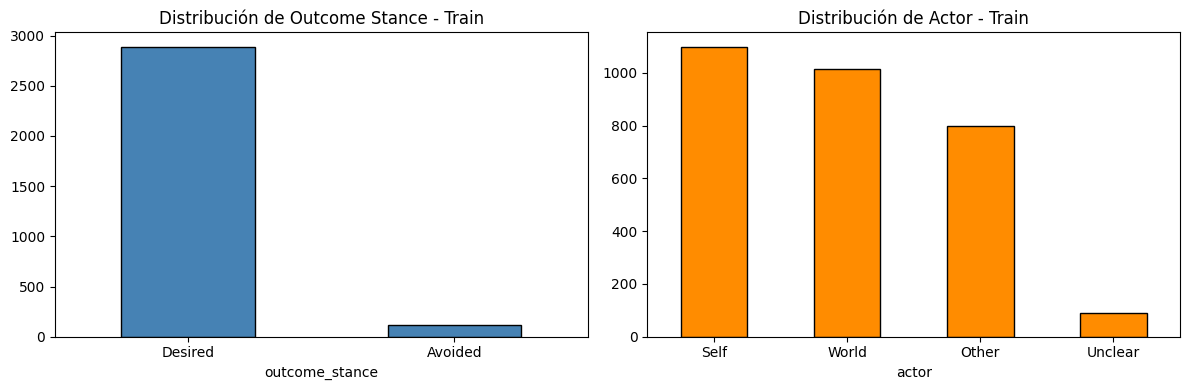

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['outcome_stance'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Outcome Stance - Train')
axes[0].tick_params(axis='x', rotation=0)

train_df['actor'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Distribución de Actor - Train')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task_d_distribution.png"), dpi=150)
plt.show()

In [9]:
# ── Pesos positivos para BCEWithLogitsLoss ────────────────────
pos_weights_stance_np = compute_class_weights(train_df, emotions_col="stance_list", labels=STANCE_LABELS)
pos_weight_stance = torch.tensor(pos_weights_stance_np) if USE_POS_WEIGHT else None

print("Pesos positivos por clase (Stance):")
for label, w in zip(STANCE_LABELS, pos_weights_stance_np):
    print(f"  {label:12s}: {w:.2f}")
    
pos_weights_actor_np = compute_class_weights(train_df, emotions_col="actor_list", labels=ACTOR_LABELS)
pos_weight_actor = torch.tensor(pos_weights_actor_np) if USE_POS_WEIGHT else None

print("\nPesos positivos por clase (Actor):")
for label, w in zip(ACTOR_LABELS, pos_weights_actor_np):
    print(f"  {label:12s}: {w:.2f}")

Pesos positivos por clase (Stance):
  Avoided     : 24.90
  Desired     : 0.04

Pesos positivos por clase (Actor):
  Self        : 1.73
  Other       : 2.76
  World       : 1.96
  Unclear     : 32.75


## 4. Tokenizador y DataLoaders

In [10]:
tokenizer = build_tokenizer(MODEL_NAME)
print(f"Tokenizer cargado: {MODEL_NAME}")

# Verificar longitudes de los spans
sample_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in train_texts[:500]]
print(f"Longitud media tokens (muestra 500): {np.mean(sample_lengths):.1f}")
print(f"Percentil 95: {np.percentile(sample_lengths, 95):.0f}")
print(f"Máximo: {max(sample_lengths)}")
print(f"MAX_LENGTH configurado: {MAX_LENGTH}")

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 21.5
Percentil 95: 49
Máximo: 91
MAX_LENGTH configurado: 512


In [11]:
# Loaders para Stance
loaders_stance = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_stance_labels,
    dev_texts=dev_texts,
    dev_labels=dev_stance_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

# Loaders para Actor
loaders_actor = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_actor_labels,
    dev_texts=dev_texts,
    dev_labels=dev_actor_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"Batches — Train: {len(loaders_stance['train'])} | Dev: {len(loaders_stance['dev'])}")

Batches — Train: 188 | Dev: 47


## 5. Comparación de Modelos

In [ ]:
list_candidate_models(multilingual_only=True)
candidate_names = [m["name"] for m in CANDIDATE_MODELS if m["multilingual"]]

In [ ]:
print("====== COMPARACIÓN PARA OUTCOME STANCE ======")
comparison_results_stance = compare_models(
    model_names=candidate_names,
    train_loader=loaders_stance["train"],
    dev_loader=loaders_stance["dev"],
    device=DEVICE,
    num_labels=len(STANCE_LABELS),
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_stance,
    save_dir=os.path.join(COMPARISON_DIR, "stance"),
    monitor_metric="f1_macro",
    early_stopping_patience=2,
)

BEST_ARCH_STANCE = comparison_results_stance.iloc[0]["model"]
print(f"\nMejor arquitectura Stance: {BEST_ARCH_STANCE}")

In [ ]:
print("\n====== COMPARACIÓN PARA ACTOR ======")
comparison_results_actor = compare_models(
    model_names=candidate_names,
    train_loader=loaders_actor["train"],
    dev_loader=loaders_actor["dev"],
    device=DEVICE,
    num_labels=len(ACTOR_LABELS),
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_actor,
    save_dir=os.path.join(COMPARISON_DIR, "actor"),
    monitor_metric="f1_macro",
    early_stopping_patience=2,
)

BEST_ARCH_ACTOR = comparison_results_actor.iloc[0]["model"]
print(f"\nMejor arquitectura Actor: {BEST_ARCH_ACTOR}")

## 6. Entrenamiento Completo de los Mejores Modelos

In [ ]:
print("====== ENTRENAMIENTO COMPLETO: OUTCOME STANCE ======")
# Construir modelo y loaders con la mejor arquitectura
model_stance = build_model(model_name=BEST_ARCH_STANCE, num_labels=len(STANCE_LABELS), dropout_prob=DROPOUT).float()

tokenizer_stance = build_tokenizer(BEST_ARCH_STANCE)
loaders_stance_full = build_all_dataloaders(
    train_texts=train_texts, train_labels=train_stance_labels,
    dev_texts=dev_texts, dev_labels=dev_stance_labels,
    tokenizer=tokenizer_stance, max_length=MAX_LENGTH, batch_size=BATCH_SIZE, num_workers=0,
)

history_stance = train(
    model=model_stance,
    train_loader=loaders_stance_full["train"],
    dev_loader=loaders_stance_full["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_stance,
    save_dir=OUTPUT_DIR,
    model_name="best_model_task_d_stance.pt",
    monitor_metric="f1_macro",
    early_stopping_patience=PATIENCE,
)

In [ ]:
print("\n====== ENTRENAMIENTO COMPLETO: ACTOR ======")
# Construir modelo y loaders con la mejor arquitectura
model_actor = build_model(model_name=BEST_ARCH_ACTOR, num_labels=len(ACTOR_LABELS), dropout_prob=DROPOUT).float()

tokenizer_actor = build_tokenizer(BEST_ARCH_ACTOR)
loaders_actor_full = build_all_dataloaders(
    train_texts=train_texts, train_labels=train_actor_labels,
    dev_texts=dev_texts, dev_labels=dev_actor_labels,
    tokenizer=tokenizer_actor, max_length=MAX_LENGTH, batch_size=BATCH_SIZE, num_workers=0,
)

history_actor = train(
    model=model_actor,
    train_loader=loaders_actor_full["train"],
    dev_loader=loaders_actor_full["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_actor,
    save_dir=OUTPUT_DIR,
    model_name="best_model_task_d_actor.pt",
    monitor_metric="f1_macro",
    early_stopping_patience=PATIENCE,
)

## 7. Evaluación Final en Dev

In [ ]:
from src.model import load_model
from src.trainer import evaluate_epoch
from src.metrics import classification_report_str

print("====== EVALUACIÓN: OUTCOME STANCE ======")
best_stance = load_model(os.path.join(OUTPUT_DIR, "best_model_task_d_stance.pt"), BEST_ARCH_STANCE, len(STANCE_LABELS), DROPOUT, DEVICE)
_, metrics_stance, probs_stance, labels_stance = evaluate_epoch(best_stance, loaders_stance_full["dev"], DEVICE, THRESHOLD, pos_weight_stance)

preds_stance = (probs_stance >= THRESHOLD).astype(int)
print(classification_report_str(labels_stance, preds_stance, target_names=STANCE_LABELS))
print(f"F1-Macro Stance: {metrics_stance['f1_macro']:.4f}")

print("\n====== EVALUACIÓN: ACTOR ======")
best_actor = load_model(os.path.join(OUTPUT_DIR, "best_model_task_d_actor.pt"), BEST_ARCH_ACTOR, len(ACTOR_LABELS), DROPOUT, DEVICE)
_, metrics_actor, probs_actor, labels_actor = evaluate_epoch(best_actor, loaders_actor_full["dev"], DEVICE, THRESHOLD, pos_weight_actor)

preds_actor = (probs_actor >= THRESHOLD).astype(int)
print(classification_report_str(labels_actor, preds_actor, target_names=ACTOR_LABELS))
print(f"F1-Macro Actor: {metrics_actor['f1_macro']:.4f}")